In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [2]:
print("Loading dataset from Kaggle...")


file_path = "zomato.csv"


df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "himanshupoddar/zomato-bangalore-restaurants",
    file_path
)

print(f"Dataset loaded successfully! Shape: {df.shape}")
print("\n--- First 5 Records ---")
print(df.head())


Loading dataset from Kaggle...
Mounting files to /kaggle/input/datasets/himanshupoddar/zomato-bangalore-restaurants...
Dataset loaded successfully! Shape: (51717, 17)

--- First 5 Records ---
                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village 

In [3]:
print("\nCleaning data...")

df = df.drop_duplicates()


cols_to_drop = ['url', 'address', 'phone', 'reviews_list', 'menu_item', 
                'listed_in(type)', 'listed_in(city)']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')


def clean_rate(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    if x == 'NEW' or x == '-':
        return np.nan
    try:
        return float(x.split('/')[0].strip())
    except:
        return np.nan

df['rate'] = df['rate'].apply(clean_rate)


df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False)
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')


df['dish_liked'] = df['dish_liked'].fillna('Unknown')
df['cuisines'] = df['cuisines'].fillna('Unknown')


df = df.dropna(subset=['rate', 'approx_cost(for two people)'])

bins = [0, 300, 600, 900, 1200, 1500, 2000, 10000]
labels = ['₹0-300', '₹301-600', '₹601-900', '₹901-1200', '₹1201-1500', '₹1501-2000', '₹2000+']
df['cost_range'] = pd.cut(df['approx_cost(for two people)'], bins=bins, labels=labels, right=True)

print(f"Data cleaning complete. Final Shape: {df.shape}")



Cleaning data...
Data cleaning complete. Final Shape: (41418, 11)


In [4]:
print("\n" + "="*60)
print("BUSINESS QUESTIONS & ANSWERS")
print("="*60)

# Q1: Which location has the highest number of restaurant outlets?
print("\nQ1: Top 5 Locations with Most Outlets:")
location_counts = df['location'].value_counts().head(5)
print(location_counts)

# Q2: What are the most popular cuisine types?
print("\nQ2: Top 5 Most Common Cuisines:")
# Split comma-separated cuisines into individual rows
all_cuisines = df['cuisines'].dropna().str.split(',').explode().str.strip()
cuisine_counts = all_cuisines.value_counts().head(5)
print(cuisine_counts)

# Q3: What is the average customer rating?
print("\nQ3: Overall Average Customer Rating:")
avg_rating = df['rate'].mean()
print(f"{avg_rating:.2f} / 5.0")

# Q4: Which location has the highest average rating? (Min 50 restaurants for significance)
print("\nQ4: Top 5 Locations with Highest Average Rating (Min 50 restaurants):")
location_stats = df.groupby('location')['rate'].agg(['mean', 'count']).reset_index()
location_stats = location_stats[location_stats['count'] >= 50] # Filter for statistical significance
top_rated_locs = location_stats.sort_values('mean', ascending=False).head(5)
print(top_rated_locs[['location', 'mean']].round(2))

# Q5: What is the most common price range for two people?
print("\nQ5: Distribution of Restaurants by Price Range:")
cost_dist = df['cost_range'].value_counts()
print(cost_dist)
most_common_price = cost_dist.idxmax()
print(f"-> Most Common Price Range: {most_common_price}")



BUSINESS QUESTIONS & ANSWERS

Q1: Top 5 Locations with Most Outlets:
location
BTM                      3906
Koramangala 5th Block    2297
HSR                      2004
Indiranagar              1803
JP Nagar                 1717
Name: count, dtype: int64

Q2: Top 5 Most Common Cuisines:
cuisines
North Indian    17310
Chinese         12930
South Indian     6369
Fast Food        6340
Continental      5202
Name: count, dtype: int64

Q3: Overall Average Customer Rating:
3.70 / 5.0

Q4: Top 5 Locations with Highest Average Rating (Min 50 restaurants):
                 location  mean
50           Lavelle Road  4.14
42  Koramangala 3rd Block  4.02
80         St. Marks Road  4.02
44  Koramangala 5th Block  4.01
12          Church Street  3.99

Q5: Distribution of Restaurants by Price Range:
cost_range
₹301-600      15906
₹0-300        12587
₹601-900       6211
₹901-1200      3044
₹1201-1500     1915
₹1501-2000     1138
₹2000+          617
Name: count, dtype: int64
-> Most Common Price Range: ₹

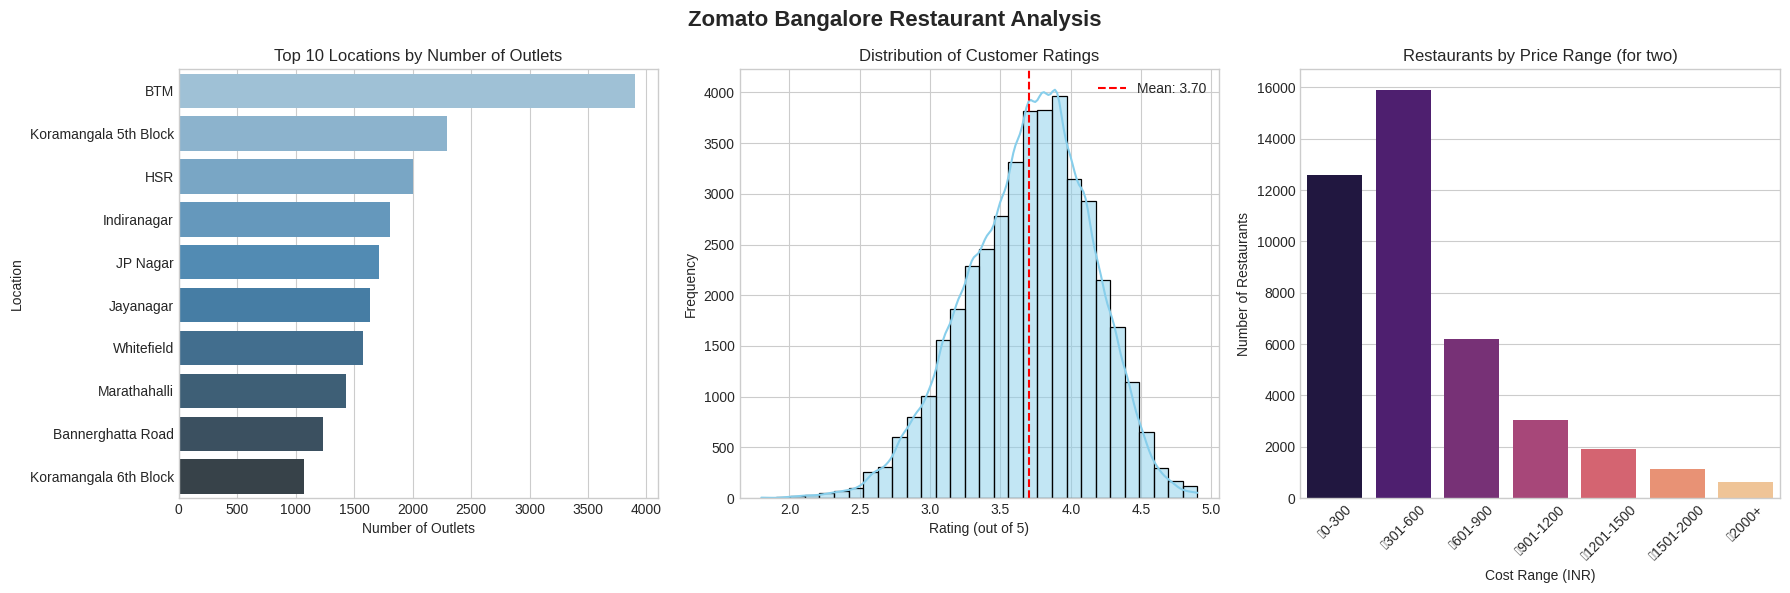

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Zomato Bangalore Restaurant Analysis', fontsize=16, fontweight='bold')

# Chart 1: 
top_locations = df['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, ax=axes[0], palette='Blues_d')
axes[0].set_title('Top 10 Locations by Number of Outlets', fontsize=12)
axes[0].set_xlabel('Number of Outlets')
axes[0].set_ylabel('Location')

# Chart 2: 
sns.histplot(df['rate'], bins=30, kde=True, ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('Distribution of Customer Ratings', fontsize=12)
axes[1].set_xlabel('Rating (out of 5)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(avg_rating, color='red', linestyle='--', label=f'Mean: {avg_rating:.2f}')
axes[1].legend()

# Chart 3: 
cost_counts = df['cost_range'].value_counts()
sns.barplot(x=cost_counts.index, y=cost_counts.values, ax=axes[2], palette='magma')
axes[2].set_title('Restaurants by Price Range (for two)', fontsize=12)
axes[2].set_xlabel('Cost Range (INR)')
axes[2].set_ylabel('Number of Restaurants')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
print("\n" + "="*60)
print("CONCLUSION")
print("="*60)
print("""
1. Market Saturation: BTM Layout, Koramangala, and Whitefield are the most saturated markets. 
   New entrants might face stiff competition here but benefit from high footfall.
2. Cuisine Preference: North Indian, Chinese, and South Indian dominate the market. 
   These are safe bets for new menus, but differentiation is key.
3. Pricing Strategy: The majority of restaurants fall in the ₹301-₹600 range for two people. 
   This indicates a highly price-sensitive mid-market segment.
4. Quality Standards: The average rating is ~3.8/5. Areas like Lavelle Road or Residency Road 
   tend to have higher averages, likely due to premium dining establishments.
5. Opportunity: There is potential in emerging suburbs with fewer outlets but growing populations, 
   offering affordable yet high-quality food to capture the mid-segment demographic.
""")


CONCLUSION

1. Market Saturation: BTM Layout, Koramangala, and Whitefield are the most saturated markets. 
   New entrants might face stiff competition here but benefit from high footfall.
2. Cuisine Preference: North Indian, Chinese, and South Indian dominate the market. 
   These are safe bets for new menus, but differentiation is key.
3. Pricing Strategy: The majority of restaurants fall in the ₹301-₹600 range for two people. 
   This indicates a highly price-sensitive mid-market segment.
4. Quality Standards: The average rating is ~3.8/5. Areas like Lavelle Road or Residency Road 
   tend to have higher averages, likely due to premium dining establishments.
5. Opportunity: There is potential in emerging suburbs with fewer outlets but growing populations, 
   offering affordable yet high-quality food to capture the mid-segment demographic.

